In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import random

# --- Function: Generate one LEO ground track ---
def generate_LEO_ground_track(inclination_deg=98.0, altitude_km=500, num_points=500, phase_offset_deg=0.0):
    EARTH_RADIUS = 6378.1  # km
    MU = 398600.4418       # km^3/s^2
    ROTATION_RATE = 360 / 86164.0  # deg/s (Earth rotation rate)

    semi_major_axis = EARTH_RADIUS + altitude_km
    period = 2 * np.pi * np.sqrt(semi_major_axis**3 / MU)
    time_steps = np.linspace(0, period, num_points)

    latitudes, longitudes = [], []
    prev_long = None

    for t in time_steps:
        mean_motion = 2 * np.pi / period
        true_anomaly = (mean_motion * t + np.radians(phase_offset_deg)) % (2 * np.pi)

        lat = np.degrees(np.arcsin(np.sin(np.radians(inclination_deg)) * np.sin(true_anomaly)))
        lon = (np.degrees(true_anomaly) - ROTATION_RATE * t) % 360
        lon = lon - 360 if lon > 180 else lon

        # Smooth longitude continuity
        if prev_long is not None:
            delta = lon - prev_long
            if delta > 180:
                lon -= 360
            elif delta < -180:
                lon += 360
        prev_long = lon

        latitudes.append(lat)
        longitudes.append(lon)

    return np.array(latitudes), np.array(longitudes)

# --- Function: Generate targets directly under the track ---
def generate_targets_under_track(latitudes, longitudes, num_targets=10, lat_offset_deg=0.05, lon_offset_deg=0.1):
    step = max(1, len(latitudes) // num_targets)
    targets = []
    for i in range(0, len(latitudes), step):
        lat = latitudes[i] + random.uniform(-lat_offset_deg, lat_offset_deg)
        lon = longitudes[i] + random.uniform(-lon_offset_deg, lon_offset_deg)
        elev = random.uniform(0, 2000)  # meters
        targets.append((lat, lon, elev))
        if len(targets) >= num_targets:
            break
    return targets

# --- Main: Multi-satellite system (different inclinations) ---
def plot_multi_satellite_tracks(
    inclinations=[97.5, 60, 45, 30],
    altitude=500,
    num_points=800
):
    fig = plt.figure(figsize=(13, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()
    ax.stock_img()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.gridlines(draw_labels=True, color='gray', alpha=0.5)

    num_sats = len(inclinations)
    phase_offset = 0
    for s, inc in enumerate(inclinations):
        # phase_offset = (360 / num_sats) * s
        color = plt.cm.plasma(s / num_sats)

        # Generate satellite ground track
        latitudes, longitudes = generate_LEO_ground_track(
            inclination_deg=inc, altitude_km=altitude,
            num_points=num_points, phase_offset_deg=phase_offset
        )

        # Plot ground track
        ax.plot(longitudes, latitudes, color=color, linewidth=2,
                label=f'Satellite {s+1}: {inc}° incl.')

        # Generate and plot targets under this track
        targets = generate_targets_under_track(latitudes, longitudes, num_targets=10)
        t_lats, t_lons, _ = zip(*targets)
        ax.scatter(t_lons, t_lats, color=color, s=25, marker='o',
                   edgecolors='black', alpha=0.7)

    ax.legend(loc='lower left', fontsize=9)
    ax.set_title(f"Multi-Satellite Ground Tracks (Different Inclinations)\nAltitude = {altitude} km",
                 fontsize=11, pad=10)

    plt.show()




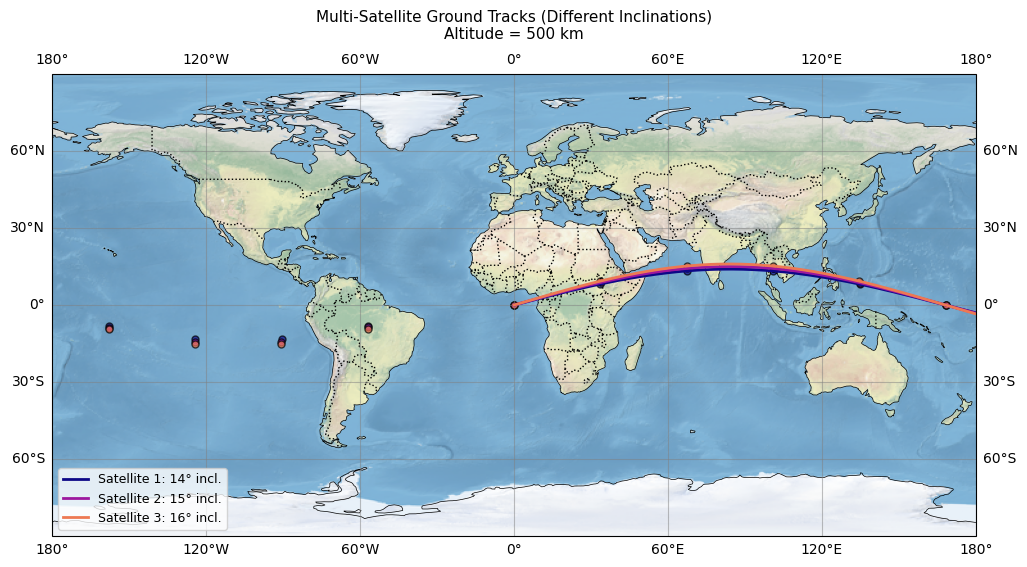

In [10]:
# --- Example run ---
plot_multi_satellite_tracks(inclinations=[14, 15, 16], altitude=500)

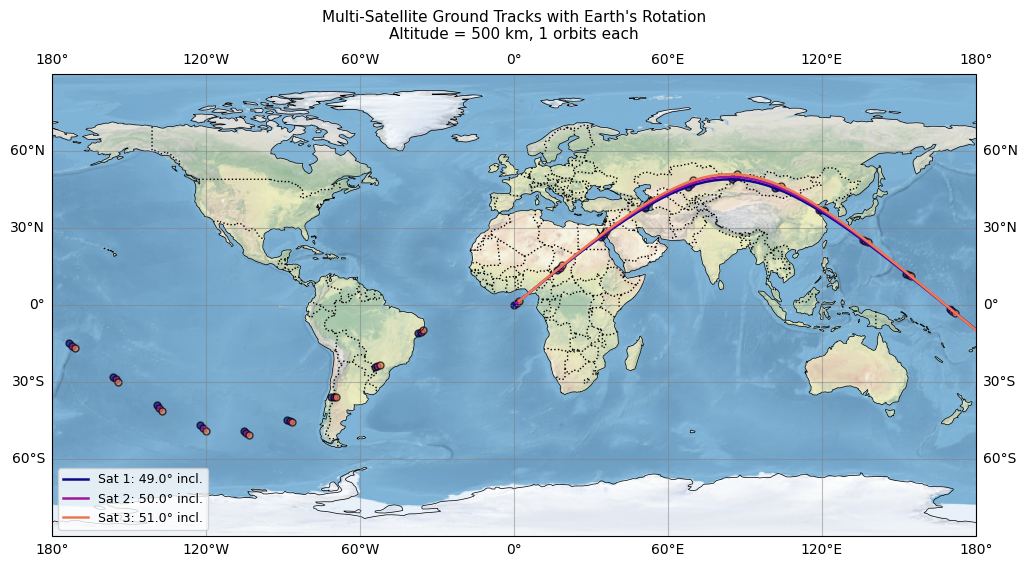

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import random

# --------------------------
# Generate a single satellite ground track
# --------------------------
def generate_LEO_ground_track(inclination_deg=98.0, altitude_km=500,
                              num_points_per_orbit=500, num_orbits=3, phase_offset_deg=0.0):
    EARTH_RADIUS = 6378.1  # km
    MU = 398600.4418       # km^3/s^2
    ROTATION_RATE = 360 / 86164.0  # deg/s (Earth rotation rate)

    semi_major_axis = EARTH_RADIUS + altitude_km
    period = 2 * np.pi * np.sqrt(semi_major_axis**3 / MU)  # seconds
    total_time = num_orbits * period
    time_steps = np.linspace(0, total_time, num_points_per_orbit * num_orbits)

    latitudes, longitudes = [], []
    prev_long = None

    for t in time_steps:
        mean_motion = 2 * np.pi / period
        true_anomaly = (mean_motion * t + np.radians(phase_offset_deg)) % (2 * np.pi)

        # Latitude from inclination
        lat = np.degrees(np.arcsin(np.sin(np.radians(inclination_deg)) * np.sin(true_anomaly)))

        # Include Earth's rotation shift
        lon = (np.degrees(true_anomaly) - ROTATION_RATE * t) % 360
        lon = lon - 360 if lon > 180 else lon

        # Prevent discontinuity when orbit crosses ±180°
        if prev_long is not None:
            delta = lon - prev_long
            if delta > 180:
                lon -= 360
            elif delta < -180:
                lon += 360
        prev_long = lon

        latitudes.append(lat)
        longitudes.append(lon)

    return np.array(latitudes), np.array(longitudes)


# --------------------------
# Generate targets directly under ground track
# --------------------------
def generate_targets_under_track(latitudes, longitudes, num_targets=50, lat_offset_deg=0.05, lon_offset_deg=0.1):
    step = max(1, len(latitudes) // num_targets)
    targets = []
    for i in range(0, len(latitudes), step):
        lat = latitudes[i] + random.uniform(-lat_offset_deg, lat_offset_deg)
        lon = longitudes[i] + random.uniform(-lon_offset_deg, lon_offset_deg)
        elev = random.uniform(0, 2000)  # meters
        targets.append((lat, lon, elev))
        if len(targets) >= num_targets:
            break
    return targets


# --------------------------
# Plot multiple satellites
# --------------------------
def plot_multi_satellite_tracks(inclinations=[98, 75, 55, 30],
                                altitude=500,
                                num_points_per_orbit=600,
                                num_orbits=3):
    fig = plt.figure(figsize=(13, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()
    ax.stock_img()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.gridlines(draw_labels=True, color='gray', alpha=0.5)

    num_sats = len(inclinations)

    for s, inc in enumerate(inclinations):
        # phase_offset = (360 / num_sats) * s  # evenly spaced in phase
        phase_offset = 0.0+s
        color = plt.cm.plasma(s / num_sats)

        # Generate track
        latitudes, longitudes = generate_LEO_ground_track(
            inclination_deg=inc,
            altitude_km=altitude,
            num_points_per_orbit=num_points_per_orbit,
            num_orbits=num_orbits,
            phase_offset_deg=phase_offset
        )

        # Plot ground track
        ax.plot(longitudes, latitudes, color=color, linewidth=1.8,
                label=f'Sat {s+1}: {inc}° incl.')

        # Generate and plot targets
        targets = generate_targets_under_track(latitudes, longitudes, num_targets=20)
        t_lats, t_lons, _ = zip(*targets)
        ax.scatter(t_lons, t_lats, color=color, s=25, marker='o',
                   edgecolors='black', alpha=0.7)

    ax.legend(loc='lower left', fontsize=9)
    ax.set_title(f"Multi-Satellite Ground Tracks with Earth's Rotation\nAltitude = {altitude} km, {num_orbits} orbits each",
                 fontsize=11, pad=10)

    plt.show()


# --------------------------
# Example run
# --------------------------
plot_multi_satellite_tracks(
    inclinations=[49.0,50.0,51.0],
    altitude=500,
    num_points_per_orbit=100,
    num_orbits=1
)


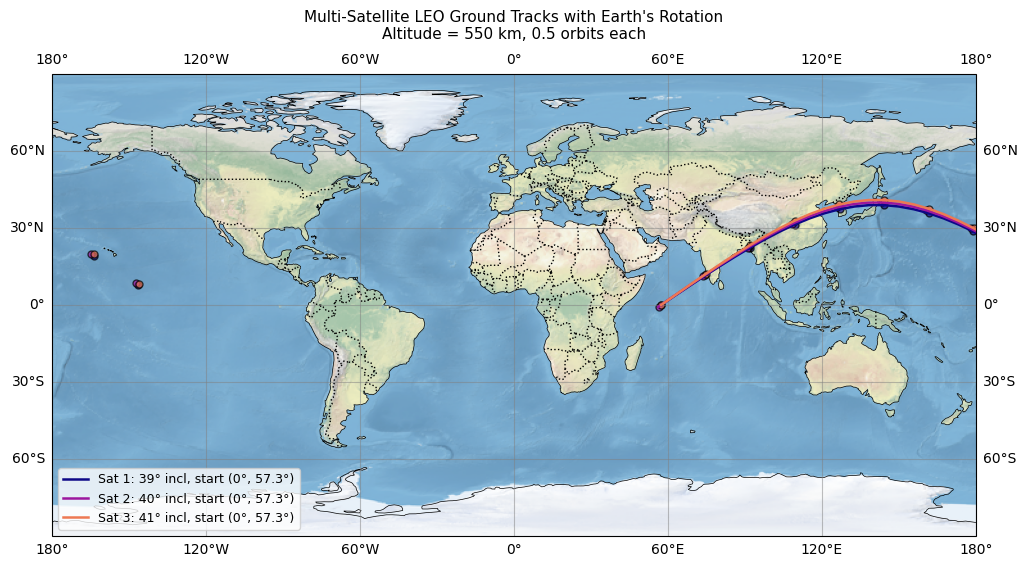

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import random

# --------------------------
# Generate a single satellite ground track
# --------------------------
def generate_LEO_ground_track(inclination_deg=98.0, altitude_km=500,
                              num_points_per_orbit=500, num_orbits=3,
                              phase_offset_deg=0.0, init_lat=0.0, init_lon=0.0):
    EARTH_RADIUS = 6378.1  # km
    MU = 398600.4418       # km^3/s^2
    ROTATION_RATE = 360 / 86164.0  # deg/s (Earth rotation rate)

    semi_major_axis = EARTH_RADIUS + altitude_km
    period = 2 * np.pi * np.sqrt(semi_major_axis**3 / MU)
    total_time = num_orbits * period
    time_steps = np.linspace(0, total_time, int(num_points_per_orbit * num_orbits))

    latitudes, longitudes = [], []
    prev_long = None

    for t in time_steps:
        mean_motion = 2 * np.pi / period
        true_anomaly = (mean_motion * t + np.radians(phase_offset_deg)) % (2 * np.pi)

        # Latitude (with offset from initial position)
        lat = np.degrees(np.arcsin(np.sin(np.radians(inclination_deg)) * np.sin(true_anomaly)))
        lat += init_lat  # shift latitude if desired
        lat = np.clip(lat, -90, 90)

        # Longitude (include Earth rotation and starting offset)
        lon = (np.degrees(true_anomaly) - ROTATION_RATE * t + init_lon) % 360
        lon = lon - 360 if lon > 180 else lon

        # Prevent discontinuity when orbit crosses ±180°
        if prev_long is not None:
            delta = lon - prev_long
            if delta > 180:
                lon -= 360
            elif delta < -180:
                lon += 360
        prev_long = lon

        latitudes.append(lat)
        longitudes.append(lon)

    return np.array(latitudes), np.array(longitudes)


# --------------------------
# Generate targets under the ground track
# --------------------------
def generate_targets_under_track(latitudes, longitudes, num_targets=10, lat_offset_deg=0.05, lon_offset_deg=0.1):
    step = max(1, len(latitudes) // num_targets)
    targets = []
    for i in range(0, len(latitudes), step):
        lat = latitudes[i] + random.uniform(-lat_offset_deg, lat_offset_deg)
        lon = longitudes[i] + random.uniform(-lon_offset_deg, lon_offset_deg)
        elev = random.uniform(0, 2000)  # meters
        targets.append((lat, lon, elev))
        if len(targets) >= num_targets:
            break
    return targets


# --------------------------
# Plot multiple satellites
# --------------------------
def plot_multi_satellite_tracks(
    inclinations=[98, 75, 55],
    altitude=500,
    num_points_per_orbit=600,
    num_orbits=3,
    init_positions=[(0, 0), (0, 0), (0, 0)]  # (lat, lon) for each satellite
):
    fig = plt.figure(figsize=(13, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()
    ax.stock_img()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.gridlines(draw_labels=True, color='gray', alpha=0.5)

    num_sats = len(inclinations)
    phase_offsets=[0,-1,0]

    for s, inc in enumerate(inclinations):
        # phase_offset = (360 / num_sats) * s  # evenly spaced in phase
        phase_offset = phase_offsets[s]
        color = plt.cm.plasma(s / num_sats)

        # Retrieve initial position (or default to 0,0)
        init_lat, init_lon = init_positions[s] if s < len(init_positions) else (0.0, 0.0)

        # Generate track
        latitudes, longitudes = generate_LEO_ground_track(
            inclination_deg=inc,
            altitude_km=altitude,
            num_points_per_orbit=num_points_per_orbit,
            num_orbits=num_orbits,
            phase_offset_deg=phase_offset,
            init_lat=init_lat,
            init_lon=init_lon
        )

        # Plot ground track
        ax.plot(longitudes, latitudes, color=color, linewidth=1.8,
                label=f'Sat {s+1}: {inc}° incl, start ({init_lat}°, {init_lon}°)')

        # Generate and plot targets
        targets = generate_targets_under_track(latitudes, longitudes, num_targets=10)
        t_lats, t_lons, _ = zip(*targets)
        ax.scatter(t_lons, t_lats, color=color, s=25, marker='o',
                   edgecolors='black', alpha=0.7)

    ax.legend(loc='lower left', fontsize=9)
    ax.set_title(f"Multi-Satellite LEO Ground Tracks with Earth's Rotation\nAltitude = {altitude} km, {num_orbits} orbits each",
                 fontsize=11, pad=10)

    plt.show()


# --------------------------
# Example run
# --------------------------
plot_multi_satellite_tracks(
    inclinations=[39,40,41],
    altitude=550,
    num_points_per_orbit=60,
    num_orbits=0.5,
    init_positions=[(0,57.3), (0, 57.3), (0, 57.3)]  # custom start positions
)
